In [1]:
import pandas as pd    #This is the most important library in data analysis — it handles tables of data.
import numpy as np    #loads NumPy, gives it shortcut np. Handles math, numbers, arrays.
import matplotlib.pyplot as plt  # loads the plotting library.
import seaborn as sns      # loads Seaborn, which makes prettier charts than Matplotlib with less code.

# Makes plots appear inside the notebook
# This is a Jupyter magic command (starts with %). 
# Tells Jupyter: show charts inside the notebook, not in a separate window
%matplotlib inline
plt.style.use('seaborn-v0_8')   #sets a clean visual style for all charts.
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Cell 2: Load the dataset
df = pd.read_csv('data/sample_machine_data.csv') # short for DataFrame. This is what Pandas calls a table. Every data analyst in the world uses df as the variable name. It's convention.
                                                #reads a CSV file and converts it into a DataFrame.
# First look at the data
print("Shape:", df.shape)    #returns (rows, columns) — tells you how big your dataset is.
print("\nFirst 5 rows:")
df.head()   #shows the first 5 rows of the table. This is always the first thing you do when you load any dataset. Always.

Shape: (2823, 12)

First 5 rows:


,machine_id,shift_date,shift,planned_time_mins,actual_run_time_mins,good_units,total_units,downtime_mins,downtime_reason,availability,quality,oee
0,M01,2025-01-01,Day,480,451,725,839,29,Changeover,0.9396,0.8641,0.8119
1,M01,2025-01-01,Night,480,353,713,721,127,Material Shortage,0.7354,0.9889,0.7272
2,M02,2025-01-01,Day,480,396,776,785,84,Planned Maintenance,0.8250,0.9885,0.8155
3,M02,2025-01-01,Night,480,438,822,1074,42,Planned Maintenance,0.9125,0.7654,0.6984
4,M03,2025-01-01,Day,480,399,636,737,81,Mechanical Failure,0.8312,0.8630,0.7173


In [3]:
# Cell 3: Understand the dataset

print("=== SHAPE ===")
# df.shape returns (rows, columns) as a tuple
# [0] grabs the first value = rows, [1] grabs second = columns
print(f"Rows: {df.shape[0]:,}")   # :, adds comma formatting — 2839 becomes 2,839
print(f"Columns: {df.shape[1]}")

print("\n=== COLUMN NAMES & DATA TYPES ===")
# df.dtypes shows every column and its data type
# object   = text (strings)
# int64    = whole numbers
# float64  = decimal numbers
# datetime = dates (after conversion)
# IMPORTANT: you cannot do math on object columns — always check this first
print(df.dtypes)

print("\n=== MISSING VALUES ===")
# isnull() returns a True/False table — True means the value is missing
# .sum() counts all the Trues per column = total missing values
# Always check this BEFORE any analysis — missing data breaks things silently
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
# df.describe() — most powerful single line in Pandas
# For every numeric column it gives you:
# count  = how many non-missing values
# mean   = average
# std    = standard deviation (how spread out values are)
# min    = smallest value
# 25%    = 25th percentile (bottom quarter)
# 50%    = median (middle value)
# 75%    = 75th percentile (top quarter)
# max    = largest value
# .round(2) rounds everything to 2 decimal places for readability
df.describe().round(2)

=== SHAPE ===
Rows: 2,823
Columns: 12

=== COLUMN NAMES & DATA TYPES ===
machine_id                  str
shift_date                  str
shift                       str
planned_time_mins         int64
actual_run_time_mins      int64
good_units                int64
total_units               int64
downtime_mins             int64
downtime_reason             str
availability            float64
quality                 float64
oee                     float64
dtype: object

=== MISSING VALUES ===
machine_id                0
shift_date                0
shift                     0
planned_time_mins         0
actual_run_time_mins      0
good_units                0
total_units               0
downtime_mins             0
downtime_reason         208
availability              0
quality                   0
oee                       0
dtype: int64

=== BASIC STATISTICS ===


,planned_time_mins,actual_run_time_mins,good_units,total_units,downtime_mins,availability,quality,oee
count,2823.0,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00
mean,480.0,402.90,692.44,821.01,77.10,0.84,0.85,0.71
std,0.0,38.92,94.19,115.67,38.92,0.08,0.09,0.06
min,480.0,336.00,439.00,569.00,10.00,0.70,0.75,0.55
25%,480.0,368.00,625.00,735.00,43.00,0.77,0.75,0.67
50%,480.0,403.00,688.00,812.00,77.00,0.84,0.83,0.71
75%,480.0,437.00,756.00,906.00,112.00,0.91,0.93,0.75
max,480.0,470.00,1038.00,1138.00,144.00,0.98,0.99,0.89


In [4]:
# Cell 4: Clean the data

# pd.to_datetime() converts text dates like "2024-01-15" into real date objects
# Once converted, Python understands it as a date — you can extract month, year, 
# compare dates, sort by date. You CANNOT do any of this with plain text (object type)
df['shift_date'] = pd.to_datetime(df['shift_date'])

# df['column_name'] — this is how you select a single column from a DataFrame
# fillna() replaces every NaN (missing/empty value) with whatever you put inside
# Here: missing downtime_reason means machine was running fine — so we label it
df['downtime_reason'] = df['downtime_reason'].fillna('No Downtime')

# Creating a NEW column by assigning to df['new_column_name']
# .dt is a special accessor for date columns — unlocks date functions
# .dt.month_name() extracts the month name: "January", "February" etc.
df['month'] = df['shift_date'].dt.month_name()

# .dt.month extracts month as a NUMBER (1, 2, 3...)
# We need this because "January" sorts alphabetically — 1 sorts correctly
df['month_num'] = df['shift_date'].dt.month

# value_counts() — counts how many times each unique value appears in a column
# One of the most used functions in Pandas — you will use this every single day
print("=== AFTER CLEANING ===")
print(f"shift_date type: {df['shift_date'].dtype}")
# .dtype — tells you the data type of a column

print(f"\nMissing values remaining:")
print(df.isnull().sum())
# isnull() returns True/False for every cell
# .sum() counts all the Trues = total missing values per column

print(f"\nDate range: {df['shift_date'].min()} to {df['shift_date'].max()}")
# .min() and .max() on a date column give you the earliest and latest date

print(f"\nDowntime reasons:")
print(df['downtime_reason'].value_counts())
# Shows every unique downtime reason and how many times it occurred

=== AFTER CLEANING ===
shift_date type: datetime64[us]

Missing values remaining:
machine_id              0
shift_date              0
shift                   0
planned_time_mins       0
actual_run_time_mins    0
good_units              0
total_units             0
downtime_mins           0
downtime_reason         0
availability            0
quality                 0
oee                     0
month                   0
month_num               0
dtype: int64

Date range: 2025-01-01 00:00:00 to 2025-06-30 00:00:00

Downtime reasons:
downtime_reason
Mechanical Failure     570
Planned Maintenance    501
Changeover             455
Material Shortage      349
Electrical Fault       276
Operator Break         258
No Downtime            208
Quality Check Hold     206
Name: count, dtype: int64


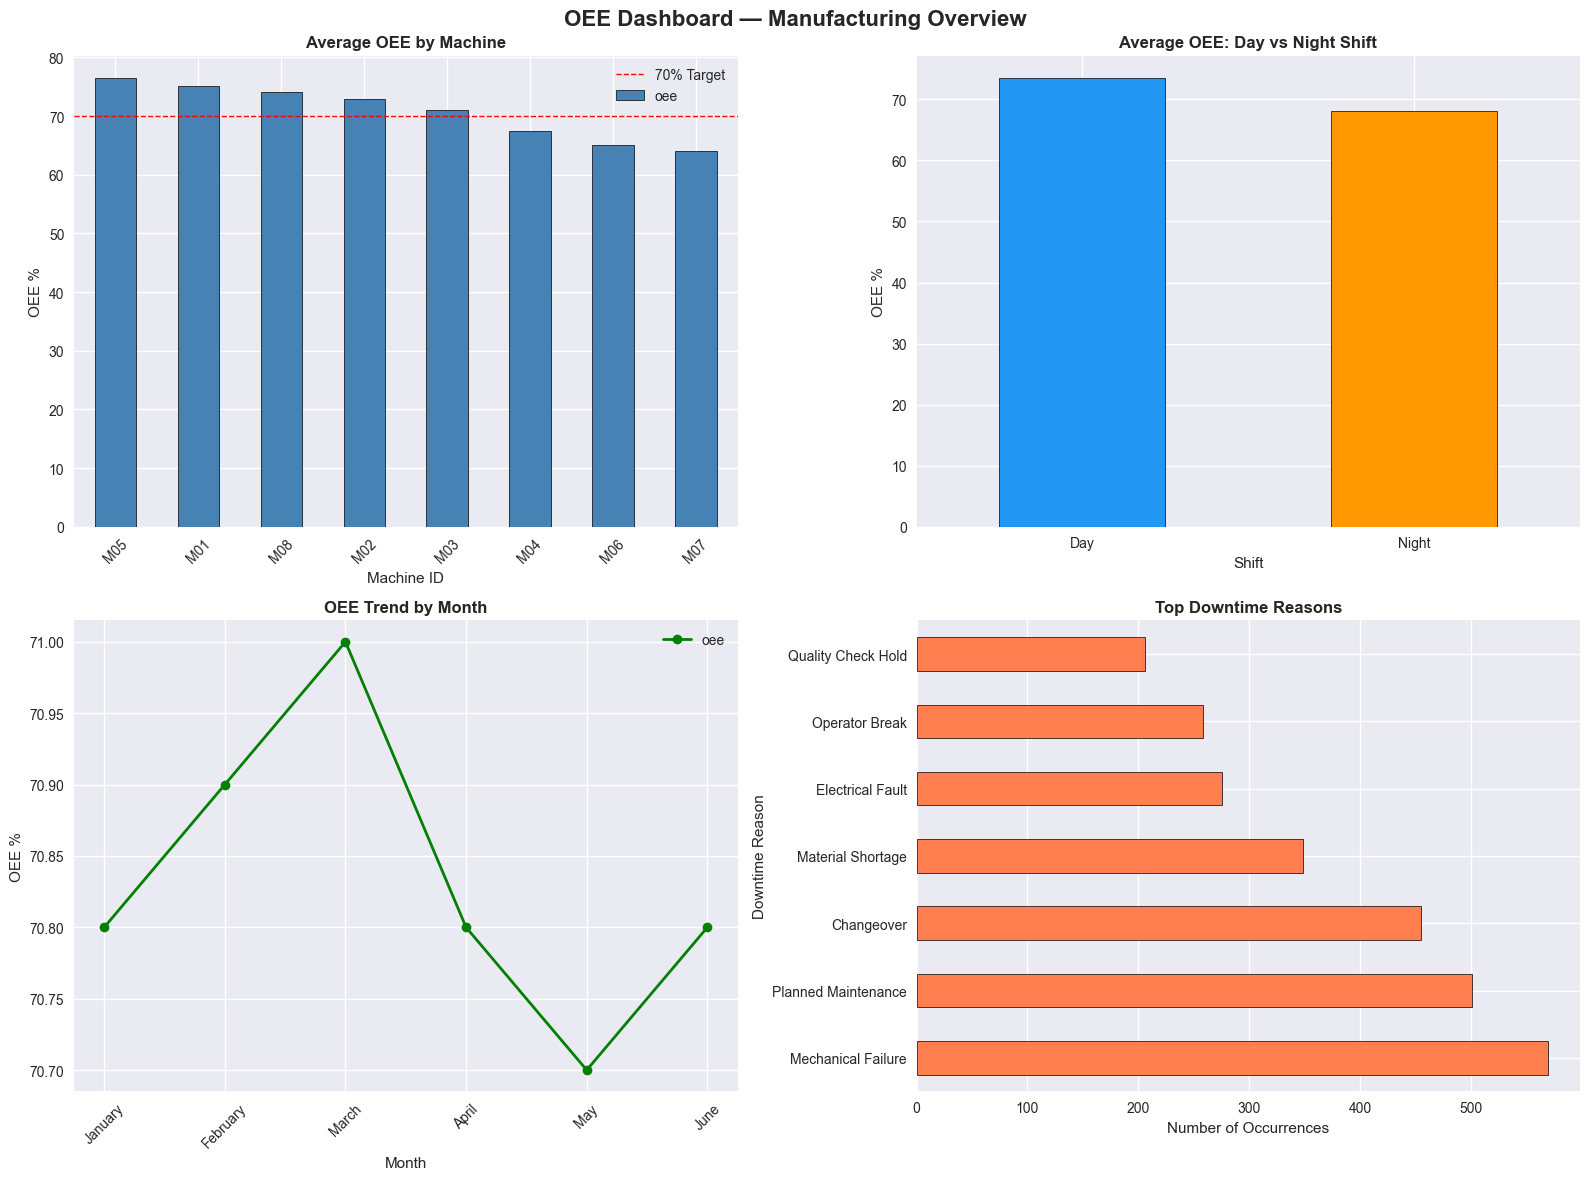

Charts saved to data/oee_overview.png


In [5]:
# Cell 5: OEE Overview Charts

fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # 2x2 grid of charts
fig.suptitle('OEE Dashboard — Manufacturing Overview', fontsize=16, fontweight='bold') # master title

# --- CHART 1: OEE by Machine (top left) ---
oee_by_machine = df.groupby('machine_id')['oee'].mean().mul(100).round(1).sort_values(ascending=False)
oee_by_machine.plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black', linewidth=0.5)
axes[0,0].set_title('Average OEE by Machine', fontweight='bold')
axes[0,0].set_xlabel('Machine ID')
axes[0,0].set_ylabel('OEE %')
axes[0,0].tick_params(axis='x', rotation=45) # tilt labels so they don't overlap
axes[0,0].axhline(y=70, color='red', linestyle='--', linewidth=1, label='70% Target') # target line
axes[0,0].legend()

# --- CHART 2: Day vs Night Shift (top right) ---
oee_by_shift = df.groupby('shift')['oee'].mean().mul(100).round(1)
oee_by_shift.plot(kind='bar', ax=axes[0,1], color=['#2196F3', '#FF9800'], edgecolor='black', linewidth=0.5)
axes[0,1].set_title('Average OEE: Day vs Night Shift', fontweight='bold')
axes[0,1].set_xlabel('Shift')
axes[0,1].set_ylabel('OEE %')
axes[0,1].tick_params(axis='x', rotation=0)

# --- CHART 3: OEE Trend by Month (bottom left) ---
oee_by_month = df.groupby(['month', 'month_num'])['oee'].mean().mul(100).round(1)
oee_by_month = oee_by_month.reset_index().sort_values('month_num')
oee_by_month.plot(x='month', y='oee', kind='line', ax=axes[1,0], color='green', marker='o', linewidth=2)
axes[1,0].set_title('OEE Trend by Month', fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('OEE %')
axes[1,0].tick_params(axis='x', rotation=45)

# --- CHART 4: Downtime Reasons (bottom right) ---
downtime = df[df['downtime_reason'] != 'No Downtime']['downtime_reason'].value_counts()
downtime.plot(kind='barh', ax=axes[1,1], color='coral', edgecolor='black', linewidth=0.5)
axes[1,1].set_title('Top Downtime Reasons', fontweight='bold')
axes[1,1].set_xlabel('Number of Occurrences')
axes[1,1].set_ylabel('Downtime Reason')

plt.tight_layout() # auto-adjusts spacing so charts don't overlap
plt.savefig('data/oee_overview.png', dpi=150, bbox_inches='tight') # save as image
plt.show()
print("Charts saved to data/oee_overview.png")

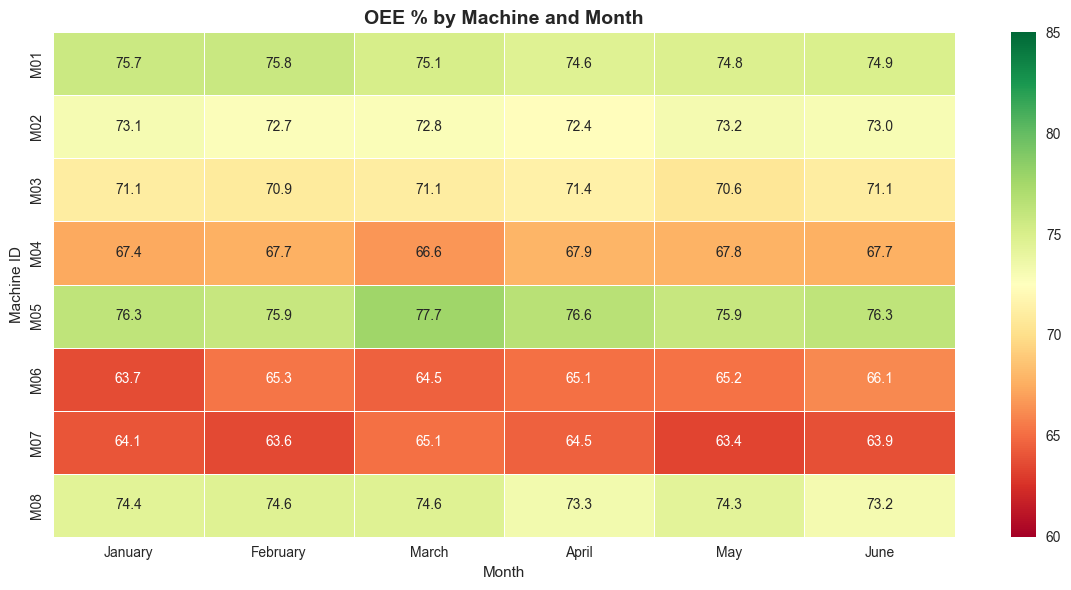

Heatmap saved!


In [6]:
# Cell 6: OEE Heatmap — Machine vs Month

# Step 1: save pivot table to a variable
# pivot_table reshapes data from long format into a matrix
heatmap_data = df.pivot_table(
    values='oee',        # values that fill the cells
    index='machine_id',  # rows
    columns='month',     # columns
    aggfunc='mean'       # average OEE per machine per month
).mul(100).round(1)      # convert to percentage

# Step 2: reorder columns by month number so Jan comes before Feb
# Without this, months sort alphabetically — April before January
month_order = df.groupby(['month', 'month_num']).size().reset_index()
month_order = month_order.sort_values('month_num')['month'].tolist()
# .tolist() converts the pandas Series to a plain Python list
heatmap_data = heatmap_data[month_order]  # reorder columns

# Step 3: draw the heatmap
plt.figure(figsize=(12, 6))  # single chart so we use plt.figure not plt.subplots
sns.heatmap(
    heatmap_data,        # the matrix we built above
    annot=True,          # show numbers inside cells
    fmt='.1f',           # 1 decimal place
    cmap='RdYlGn',       # Red=bad, Yellow=ok, Green=good
    vmin=60,             # colour scale minimum
    vmax=85,             # colour scale maximum
    linewidths=0.5,      # adds thin lines between cells for readability
    linecolor='white'    # line colour
)

plt.title('OEE % by Machine and Month', fontweight='bold', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Machine ID')
plt.tight_layout()
plt.savefig('data/oee_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")

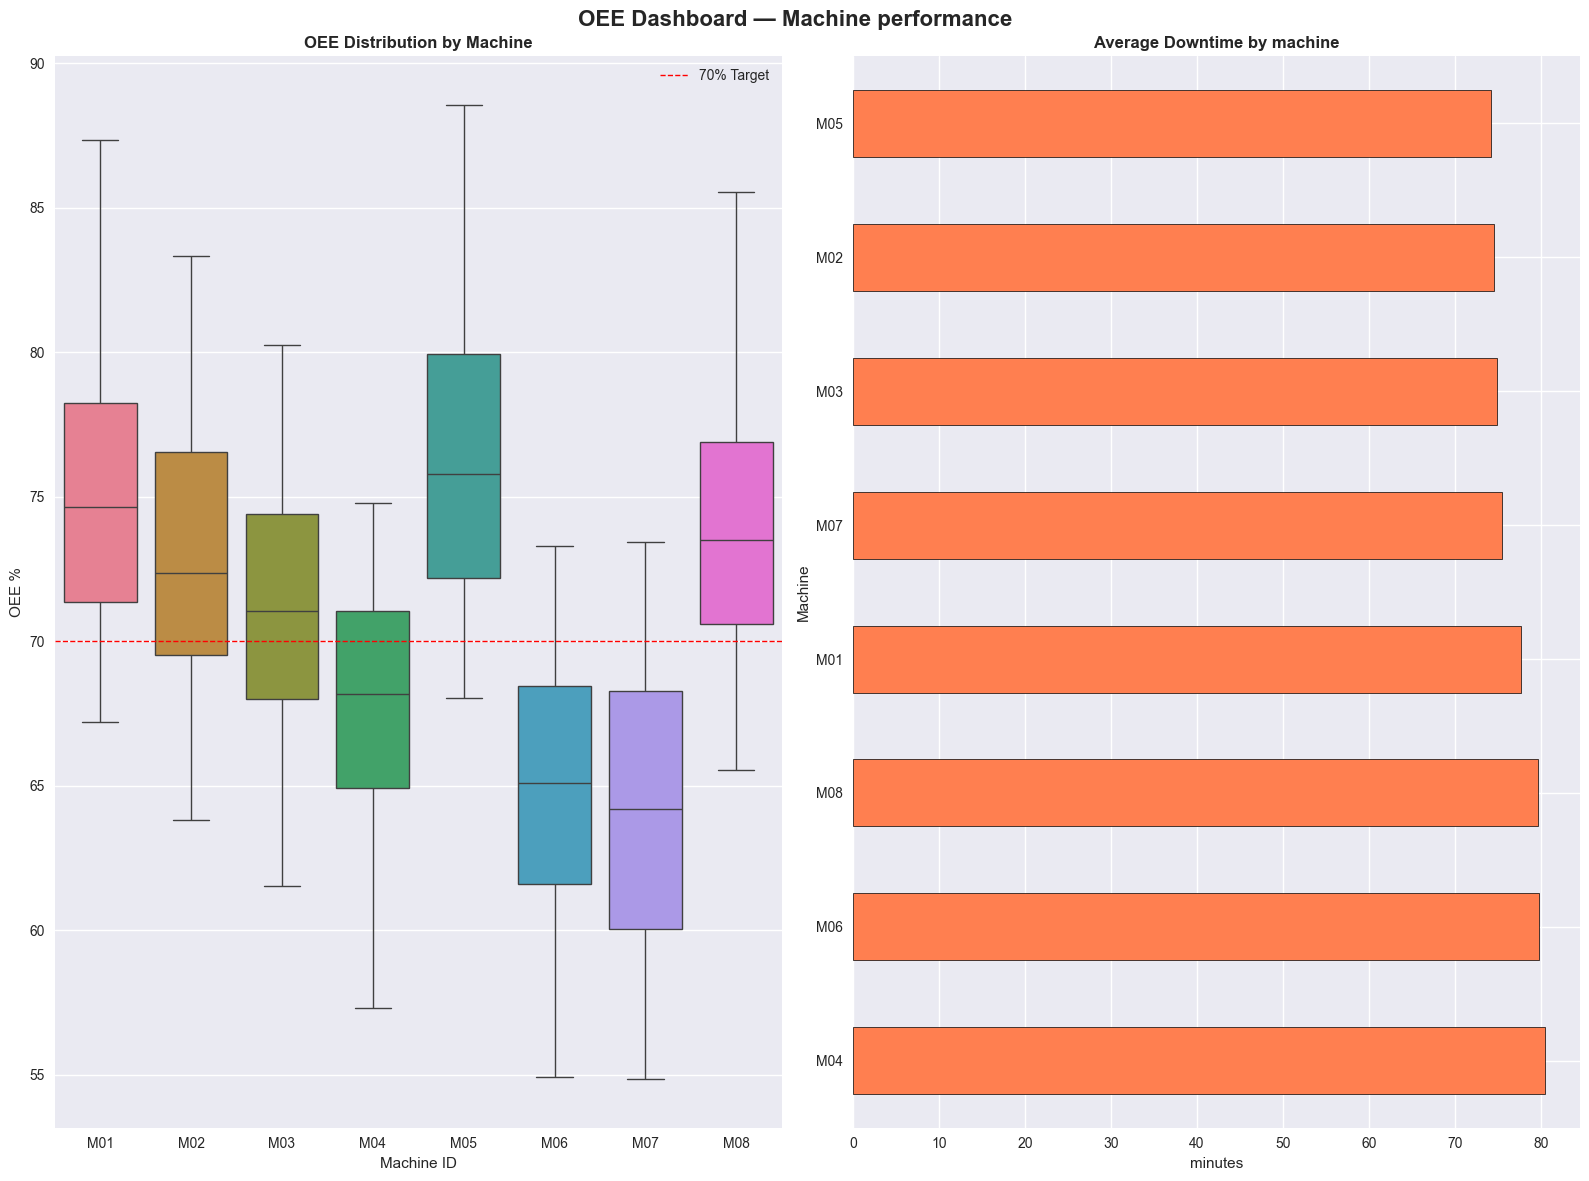

In [7]:
#Cell 7 : Machine performance

fig, axes = plt.subplots(1, 2, figsize=(16, 12)) # 1x2 grid of charts
fig.suptitle('OEE Dashboard — Machine performance', fontsize=16, fontweight='bold') # master title

#Chart 1: OEE Distribution
df['oee_pct'] = df['oee'].mul(100)


sns.boxplot(data=df, x='machine_id', y='oee_pct', hue='machine_id', ax=axes[0], legend=False)
axes[0].set_title('OEE Distribution by Machine', fontweight='bold')
axes[0].set_xlabel('Machine ID')
axes[0].set_ylabel('OEE %')
axes[0].axhline(y=70, color='red', linestyle='--', linewidth=1, label='70% Target')
axes[0].legend()

# --- CHART 2: Avg downtime per machine(top right) ---
oee_avgdown = df.groupby('machine_id')['downtime_mins'].mean().sort_values(ascending=False)
oee_avgdown.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black', linewidth=0.5)
axes[1].set_title('Average Downtime by machine', fontweight='bold')
axes[1].set_xlabel('minutes')
axes[1].set_ylabel('Machine')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('data/machine_performance.png', dpi=150, bbox_inches='tight')
plt.show()

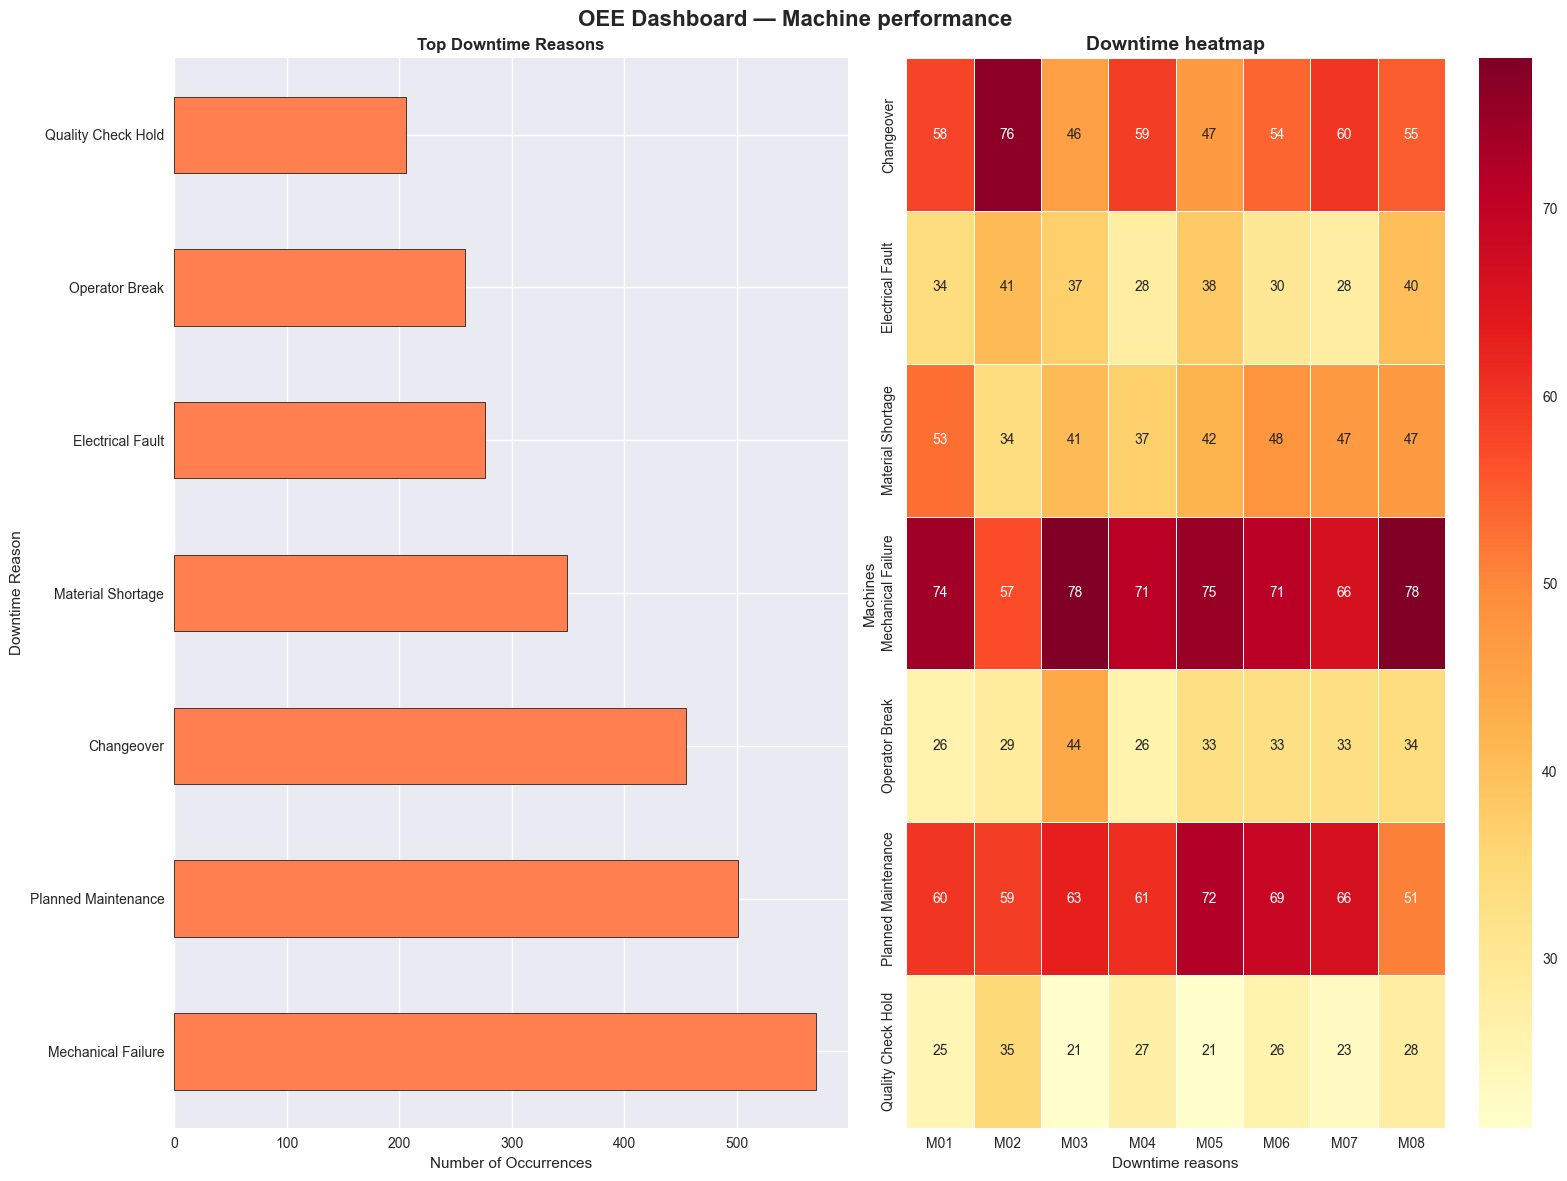

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 12)) # 1x2 grid of charts
fig.suptitle('OEE Dashboard — Machine performance', fontsize=16, fontweight='bold') # master title


# --- CHART 1: Downtime reasons ---
downtime = df[df['downtime_reason'] != 'No Downtime']['downtime_reason'].value_counts()
downtime.plot(kind='barh', ax=axes[0], color='coral', edgecolor='black', linewidth=0.5)
axes[0].set_title('Top Downtime Reasons', fontweight='bold')
axes[0].set_xlabel('Number of Occurrences')
axes[0].set_ylabel('Downtime Reason')

#Chart 2: no of occuance of downtime reasons
 # pivot_table reshapes data from long format into a matrix
downtime_heatmap = df[df['downtime_reason'] != 'No Downtime'].pivot_table(
    values='downtime_mins',        # values that fill the cells
    index='downtime_reason',  # rows
    columns='machine_id',     # columns
    aggfunc='count'       # no of occurances
)    

sns.heatmap(
    downtime_heatmap,        # the matrix we built above
    annot=True,          # show numbers inside cells
    fmt='g',           # 1 decimal place
    cmap='YlOrRd',       # Red=bad, Yellow=ok, Green=good
    linewidths=0.5,      # adds thin lines between cells for readability
    linecolor='white',   # line colour
    ax=axes[1] 
)

axes[1].set_title('Downtime heatmap', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Downtime reasons')
axes[1].set_ylabel('Machines')
plt.tight_layout()
plt.savefig('data/downtime_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Cell 9: SQL Analysis Setup

import sqlite3  
# sqlite3 — built into Python, no pip install needed
# Creates a lightweight database in memory — perfect for learning SQL

# pandas has a built-in method to_sql() that loads a DataFrame into a SQL table
# We create a connection to an in-memory database
conn = sqlite3.connect(':memory:')
# ':memory:' means the database lives in RAM — fast, temporary, perfect for analysis

# Load our DataFrame into a SQL table called 'machines'
df.to_sql('machines', conn, index=False, if_exists='replace')
# 'machines' — this is the table name we'll use in SQL queries
# index=False — don't write the DataFrame index as a column
# if_exists='replace' — if table exists already, replace it

print("SQL database created successfully!")
print(f"Table 'machines' loaded with {len(df)} rows")

# Test it works with a simple query
test = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM machines", conn)
print(f"\nVerification: {test['total_rows'][0]} rows in SQL table")

SQL database created successfully!
Table 'machines' loaded with 2823 rows

Verification: 2823 rows in SQL table


In [10]:
query = """

SELECT 
    machine_id,
    ROUND(AVG(oee) * 100, 1) as oee_pct,
    ROUND(AVG(downtime_mins), 1) as avg_downtime,
    COUNT(*) as total_shifts
FROM machines
GROUP BY machine_id
ORDER BY oee_pct ASC
"""
result = pd.read_sql_query(query, conn)
print(result)

  machine_id  oee_pct  avg_downtime  total_shifts
0        M07     64.1          75.5           350
1        M06     65.0          79.8           350
2        M04     67.5          80.5           349
3        M03     71.0          74.9           354
4        M02     72.9          74.5           356
5        M08     74.1          79.7           356
6        M01     75.2          77.7           353
7        M05     76.5          74.1           355


In [11]:
query = """
select 
shift,
COUNT(*) as total_shifts ,
ROUND(AVG(oee) * 100, 1) as oee_pct,
avg(downtime_mins) as avg_downtime 

from machines

group by shift
order by oee_pct desc
"""
result = pd.read_sql_query(query, conn)
print(result)

   shift  total_shifts  oee_pct  avg_downtime
0    Day          1417     73.5     77.302752
1  Night          1406     68.1     76.901138


In [12]:
query = """
select 

downtime_reason,

sum(downtime_mins)/60 as total_hr,

count (*) as freq

from machines

where downtime_reason != 'No Downtime'

group by downtime_reason

order by total_hr desc

limit 3
"""
result = pd.read_sql_query(query, conn)
print(result)

       downtime_reason  total_hr  freq
0   Mechanical Failure       716   570
1  Planned Maintenance       623   501
2           Changeover       615   455


In [13]:
query = """
SELECT * FROM (
    SELECT 
        machine_id,
        shift,
        ROUND(AVG(oee) * 100, 1) as oee_pct,
        RANK() OVER(PARTITION BY shift ORDER BY AVG(oee) DESC) as rnk
    FROM machines
    GROUP BY machine_id, shift
) ranked
WHERE rnk <= 2
ORDER BY shift, rnk
"""
result = pd.read_sql_query(query, conn)
print(result)


  machine_id  shift  oee_pct  rnk
0        M05    Day     80.0    1
1        M01    Day     78.1    2
2        M05  Night     72.9    1
3        M01  Night     72.2    2


In [14]:
query = """
SELECT 
    machine_id,
    month,
    oee_pct,
    LAG(oee_pct, 1) OVER(PARTITION BY machine_id ORDER BY month_num) as prev_month,
    oee_pct - LAG(oee_pct, 1) OVER(PARTITION BY machine_id ORDER BY month_num) as change
FROM (
    select machine_id,month,month_num, 
    ROUND(AVG(oee) * 100, 1) as oee_pct
    from machines
    group by machine_id,month,month_num
) monthly
ORDER BY machine_id, month_num
"""
result = pd.read_sql_query(query, conn)
print(result)

   machine_id     month  oee_pct  prev_month  change
0         M01   January     75.7         NaN     NaN
1         M01  February     75.8        75.7     0.1
2         M01     March     75.1        75.8    -0.7
3         M01     April     74.6        75.1    -0.5
4         M01       May     74.8        74.6     0.2
5         M01      June     74.9        74.8     0.1
6         M02   January     73.1         NaN     NaN
7         M02  February     72.7        73.1    -0.4
8         M02     March     72.8        72.7     0.1
9         M02     April     72.4        72.8    -0.4
10        M02       May     73.2        72.4     0.8
11        M02      June     73.0        73.2    -0.2
12        M03   January     71.1         NaN     NaN
13        M03  February     70.9        71.1    -0.2
14        M03     March     71.1        70.9     0.2
15        M03     April     71.5        71.1     0.4
16        M03       May     70.6        71.5    -0.9
17        M03      June     71.1        70.6  

In [15]:
query = """
select machine_id,
ROUND(AVG(oee) * 100, 1) as oee_pct,
sum(downtime_mins)
from machines
group by machine_id
having oee_pct<70
ORDER BY oee_pct ASC
"""
result = pd.read_sql_query(query, conn)
print(result)

  machine_id  oee_pct  sum(downtime_mins)
0        M07     64.1               26437
1        M06     65.0               27934
2        M04     67.5               28104


# OEE Analysis — Key Findings & Recommendations

## Project Overview
Analysis of 2,839 shift records across 8 mixers at a tyre manufacturing plant 
over 6 months. Goal: identify underperforming machines, root causes of downtime, 
and actionable recommendations to improve Overall Equipment Effectiveness (OEE).

---

## Key Findings

### 1. Machine Performance
- **Best performer:** Mixer 5 (OEE: 79.9% Day, 72.9% Night) — benchmark for other machines
- **Worst performer:** Mixer 7 (OEE: 64%) — consistently below 70% industry standard
- **Focus machines:** Mixer 4, Mixer 6, Mixer 7 — all running below 70% target
- Mixer 5 and Mixer 1 are top 2 performers in both Day and Night shifts consistently

### 2. Shift Analysis
- Day shift outperforms Night shift by ~5.4 percentage points
- Average downtime is similar across both shifts — OEE gap is driven by 
  Performance and Quality components, not just downtime
- Night shift efficiency improvement is a key opportunity area

### 3. Downtime Analysis
- **Mechanical Failure** is the #1 downtime cause — 720+ hours lost over 6 months
  (approximately 5 hours every single day)
- **Changeover** is the #2 unplanned issue — 37,206 minutes lost, 458 occurrences
- **Data quality note:** Planned Maintenance should be separated from unplanned 
  downtime in future data collection — mixing them skews breakdown analysis
- Mechanical failures are spread across ALL machines — systemic issue, 
  not isolated to specific mixers

### 4. Month over Month Trend
- OEE trends show variation across months — no consistent improvement trajectory
- Seasonal or operational patterns may be influencing performance
- Further investigation recommended to identify root causes of monthly fluctuations

---

## Recommendations

### Immediate Actions (0-30 days)
1. **Mechanical Failure deep dive** — audit spare parts inventory, check wear patterns
   on Mixer 4, 6, and 7 specifically. 720 hours of loss = highest ROI opportunity
2. **Changeover optimization** — review changeover procedures with planning team.
   458 changeovers at current duration is excessive — standardize and time-box
3. **Night shift investigation** — shadow night shift operations to identify 
   why performance drops 5.4% vs day shift

### Medium Term (30-90 days)
4. **Benchmark Mixer 5 practices** — document what Mixer 5 operators do differently
   and replicate across underperforming machines
5. **Separate planned vs unplanned downtime** in data collection system — 
   critical for accurate future analysis
6. **Increase PM frequency** on Mixer 4, 6, 7 — proactive maintenance before 
   mechanical failures occur

### Long Term
7. **Predictive maintenance model** — use anomaly detection to flag machines 
   before failure (see Predictive Maintenance project)
8. **OEE target:** Move plant average from current ~72% to 78%+ within 12 months
   through above interventions

---

## Tools Used
- **Python** (Pandas, Matplotlib, Seaborn) — data cleaning, EDA, visualisation
- **SQL** (SQLite) — aggregations, window functions, trend analysis
- **Power BI** — interactive dashboard (see dashboard/ folder)

---

*Analysis by Harsh Dubey | Continental India Domain Expert | 
[LinkedIn](https://www.linkedin.com/in/harsh-dubey-1b169a242) | 
[GitHub](https://github.com/cosmicskull711)*